# Lachesis Stop Detection

The first stop detection algorithm implemented in ```nomad``` is a sequential algorithm insipired by the one in _Project Lachesis: Parsing and Modeling Location Histories_ (Hariharan & Toyama). This algorithm for extracting stays is dependent on two parameters: the roaming distance and the stay duration. 

* Roaming distance represents the maximum distance an object can move away from a point location and still be considered to be staying at that location.
* Stop duration is the minimum amount of time an object must spend within the roaming distance of a location to qualify as a stop.

The algorithm identifies stops as contiguous sequences of pings that stay within the roaming distance for at least the duration of the stop duration.

This algorithm has the following parameters, which determine the size of the resulting stops:
* ```dur_min```: Minimum duration for a stay in minutes.
* ```dt_max```: Maximum time gap permitted between consecutive pings in a stay in minutes (dt_max should be greater than dur_min).
* ```delta_roam```: Maximum roaming distance for a stay in meters.

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.dbscan as DBSCAN

import nomad.data as data_folder
from pathlib import Path
from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations

In [217]:
# Parameters according to the config file
with open('config_low_ha.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

# users = loader.sample_users(config["output_files"]["diaries_path"], format='parquet', size = 600)
# tc = {"x": "x", "y": "y", "timestamp": "timestamp"}

city = City.from_geopackage(config["city_file"])

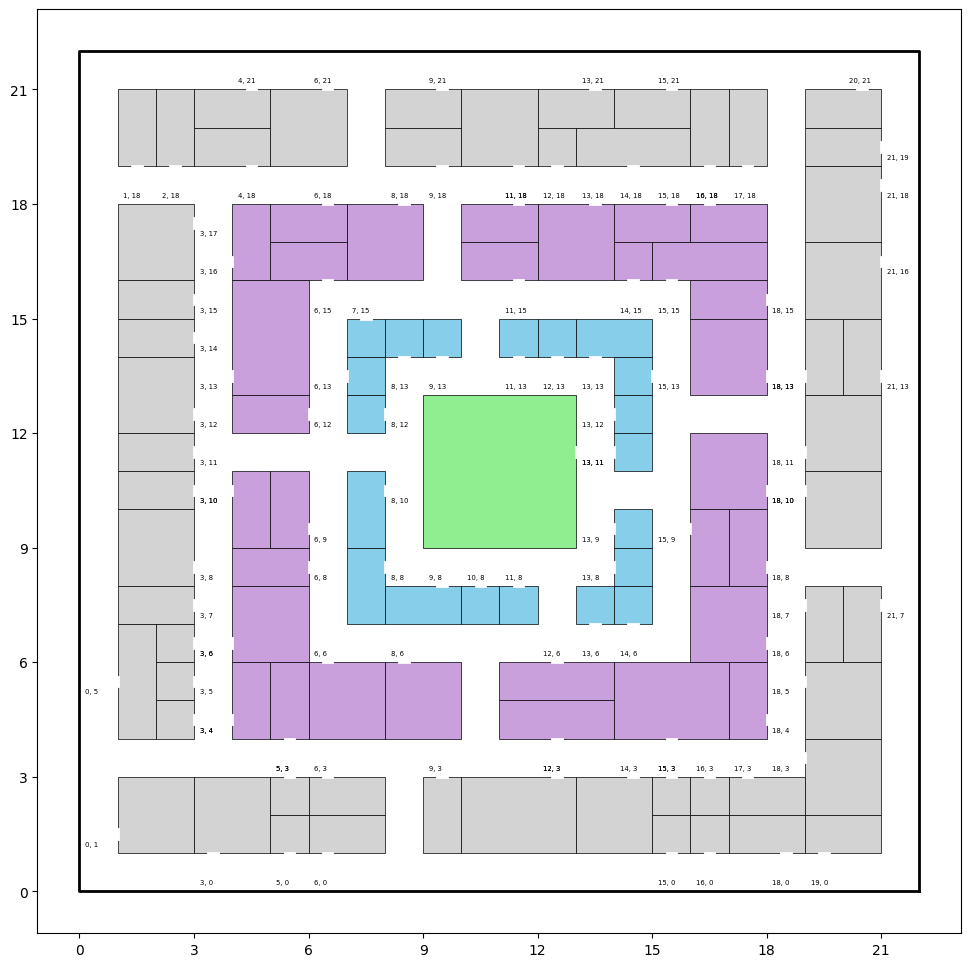

In [3]:
fig, ax = plt.subplots(figsize=(12,12))

city.plot_city(ax=ax)

# Destination Diary

In [139]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=6, freq='30min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [30]*6  # in minutes
# location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 1
location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 2 + ['h-x14-y11'] * 1


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)

In [151]:
Charlie = Agent(identifier="Charlie",
                city=city)

# Convert datetime column
# destinations['datetime'] = pd.to_datetime(destinations['datetime'])
Charlie.generate_trajectory(destination_diary=destinations,
                            seed=19104,
                            dt=0.25)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=4,
                          seed=215,
                          ha=10/15)

In [141]:
def plot_time_barcode_colored(ts_series, cluster_labels, ax, cmap='tab20c', 
                               noise_color='black', set_xlim=True):
    """
    Plot a barcode of timestamps colored by their stop cluster.
    
    Parameters
    ----------
    ts_series : pd.Series
        Timestamps (unix seconds).
    cluster_labels : pd.Series
        Cluster labels for each timestamp (-1 for noise/non-stop points).
    ax : matplotlib.axes.Axes
        Axis to draw on.
    cmap : str or Colormap, default 'tab20c'
        Colormap for cluster colors.
    noise_color : color, default 'black'
        Color for noise points (cluster -1).
    set_xlim : bool, default True
        Auto-set x-axis limits with padding.
    
    Returns
    -------
    list
        List of vline collections.
    """
    ts_dt = pd.to_datetime(ts_series, unit='s')
    
    if set_xlim:
        pad = pd.Timedelta(minutes=20)
        ax.set_xlim(ts_dt.min() - pad, ts_dt.max() + pad)
    
    # Get unique clusters (excluding noise)
    unique_clusters = cluster_labels.unique()
    unique_clusters = unique_clusters[unique_clusters >= 0]
    num_clusters = len(unique_clusters)
    
    # Get colormap
    cmap_obj = plt.get_cmap(cmap)
    
    vlines = []
    
    # Plot noise points
    noise_mask = cluster_labels == -1
    if noise_mask.any():
        vlines.append(ax.vlines(ts_dt[noise_mask], 0.2, 0.8, 
                                colors=noise_color, lw=1, alpha=0.5))
    
    # Plot each cluster with its color
    if num_clusters > 0:
        for cid in unique_clusters:
            cluster_mask = cluster_labels == cid
            if cluster_mask.any():
                col = cmap_obj(cid / num_clusters)
                vlines.append(ax.vlines(ts_dt[cluster_mask], 0.2, 0.8, 
                                       colors=col, lw=1, alpha=1, zorder=2))
    
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    
    # Time axis formatting
    time_range = (ts_dt.max() - ts_dt.min()).total_seconds()
    
    if time_range <= 3600 * 12:
        major_locator = mdates.HourLocator(interval=1)
        formatter = mdates.DateFormatter('%I %p')
        minor_locator = None
    elif time_range <= 3600 * 72:
        major_locator = mdates.HourLocator(interval=6)
        formatter = mdates.DateFormatter('%I %p')
        minor_locator = mdates.HourLocator(interval=1)
    else:
        major_locator = mdates.DayLocator()
        formatter = mdates.DateFormatter('%a\n%I %p')
        minor_locator = mdates.HourLocator(interval=6)
    
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(formatter)
    
    if minor_locator is not None:
        ax.xaxis.set_minor_locator(minor_locator)
        ax.tick_params(axis='x', which='minor', length=3)
    
    ax.tick_params(axis='x', which='major', labelsize=10)
    
    return vlines

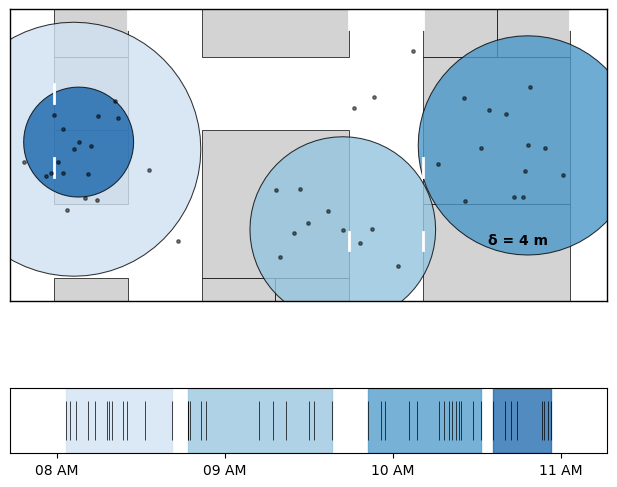

In [142]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# outer_box = box(*city.city_boundary.bounds)
delta_roam = 4
stops = LACHESIS.lachesis(Charlie.sparse_traj, delta_roam=delta_roam, dt_max=40, dur_min=5, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=40, delta_roam=delta_roam, dur_min=5)


fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

plot_stops(stops, ax=ax_map, cmap='Blues')
plot_pings(Charlie.sparse_traj, ax=ax_map, s=6, color='black', alpha=0.5)

# Add border instead of turning off axis
ax_map.spines['top'].set_visible(True)
ax_map.spines['right'].set_visible(True)
ax_map.spines['bottom'].set_visible(True)
ax_map.spines['left'].set_visible(True)
ax_map.spines['top'].set_linewidth(1)
ax_map.spines['right'].set_linewidth(1)
ax_map.spines['bottom'].set_linewidth(1)
ax_map.spines['left'].set_linewidth(1)
ax_map.set_xticks([])
ax_map.set_yticks([])

# # Add delta_roam scale indicator (bottom-right corner)
x_range = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
y_range = ax_map.get_ylim()[1] - ax_map.get_ylim()[0]
scale_x = ax_map.get_xlim()[1] - 0.15 * x_range  # Position from right
scale_y = ax_map.get_ylim()[0] + 0.08 * y_range  # Position from bottom


# # Add label
ax_map.text(scale_x, scale_y + 0.4, f'δ = {delta_roam} m', 
           ha='center', va='bottom', fontsize=10, fontweight='bold', zorder=10)

plot_time_barcode(Charlie.sparse_traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, cmap='Blues', set_xlim=False, timestamp='timestamp')

plt.tight_layout(pad=0.1)
plt.show()

/var/folders/nt/0tc5pmb17xd73rr4g1xb0g_00000gn/T/ipykernel_15849/467186859.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


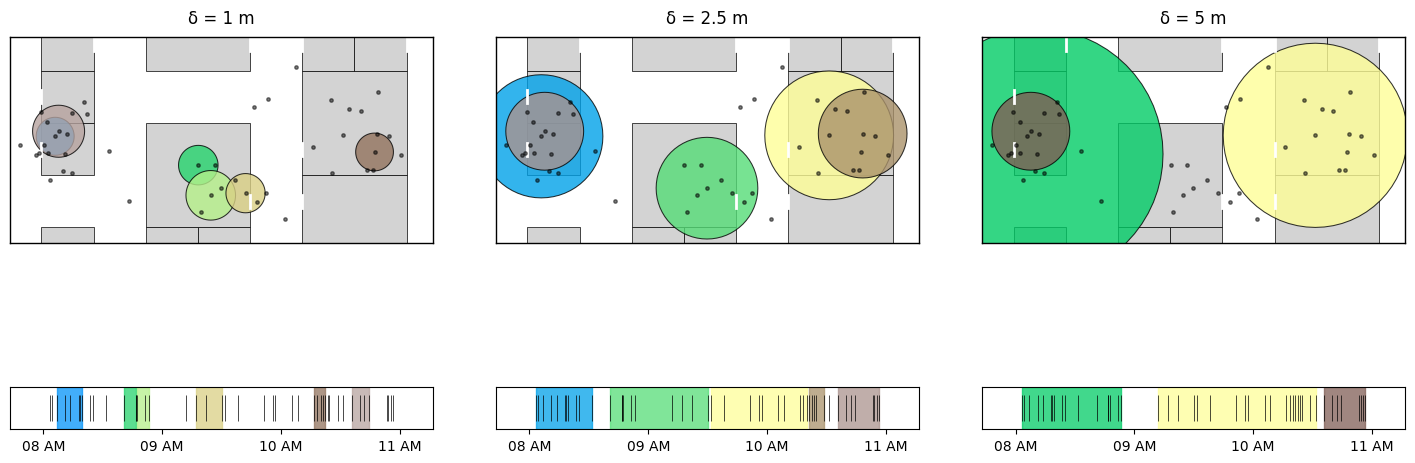

In [143]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Define delta_roam values for comparison
delta_roam_values = [1, 2.5, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 6.5),
                        gridspec_kw={'height_ratios': [10, 1], 'hspace': 0.15, 'wspace': 0.15})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2

for i, delta_roam in enumerate(delta_roam_values):
    # Run Lachesis with current delta_roam
    stops = LACHESIS.lachesis(Charlie.sparse_traj, 
                             delta_roam=delta_roam, 
                             dt_max=40, 
                             dur_min=5, 
                             complete_output=True, 
                             keep_col_names=True, 
                             timestamp='timestamp')
    
    # Map subplot
    ax_map = axes[0, i]
    ax_map.set_xlim(13.4, 21.5)
    ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
    
    city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)
    plot_stops(stops, ax=ax_map, cmap='terrain')
    plot_pings(Charlie.sparse_traj, ax=ax_map, s=6, color='black', alpha=0.5)
    
    # Add border
    ax_map.spines['top'].set_visible(True)
    ax_map.spines['right'].set_visible(True)
    ax_map.spines['bottom'].set_visible(True)
    ax_map.spines['left'].set_visible(True)
    ax_map.spines['top'].set_linewidth(1)
    ax_map.spines['right'].set_linewidth(1)
    ax_map.spines['bottom'].set_linewidth(1)
    ax_map.spines['left'].set_linewidth(1)
    ax_map.set_xticks([])
    ax_map.set_yticks([])
    
    # Add delta_roam scale indicator
    x_range = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
    y_range = ax_map.get_ylim()[1] - ax_map.get_ylim()[0]
    scale_x = ax_map.get_xlim()[1] - 0.15 * x_range
    scale_y = ax_map.get_ylim()[0] + 0.08 * y_range
    
    # Add subplot title
    ax_map.set_title(f'δ = {delta_roam} m', fontsize=12, pad=10)
    
    # Barcode subplot
    ax_barcode = axes[1, i]
    plot_time_barcode(Charlie.sparse_traj['timestamp'], ax=ax_barcode, set_xlim=True)
    plot_stops_barcode(stops, ax=ax_barcode, cmap='terrain', set_xlim=False, timestamp='timestamp')

plt.savefig('diff_deltas_clusters.svg', format='svg')
plt.tight_layout(pad=0.1)
plt.show()


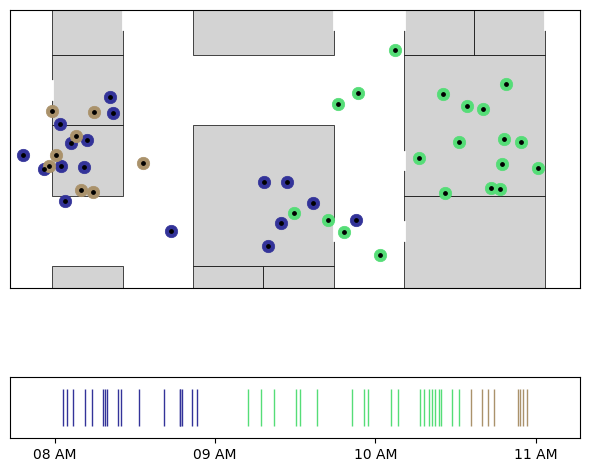

<Figure size 640x480 with 0 Axes>

In [144]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

labels = LACHESIS.lachesis_labels(
    data=Charlie.sparse_traj,
    dt_max=30,
    delta_roam=5,
    dur_min=5)


city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

# ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
#            color='red', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_clusters.svg', format='svg')

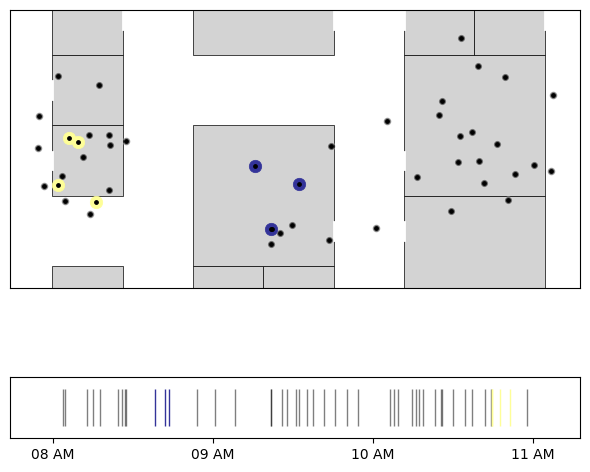

In [222]:
import nomad.filters as filters 
import nomad.stop_detection.grid_based as GRID_BASED

fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}


# normal
# labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=30, delta_roam=3, dur_min=5)

# many visits one point
# labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=30, delta_roam=2, dur_min=5)

# temporal overlap DBSCAN
# labels = DBSCAN.ta_dbscan_labels(Charlie.sparse_traj, time_thresh=180, dist_thresh=1, min_pts=3)

# splitting
# labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=30, delta_roam=1, dur_min=5)

# missingness
labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=4, delta_roam=1, dur_min=5)


city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

# ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
#            color='red', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.savefig('missing_clusters.svg', format='svg')
plt.show()

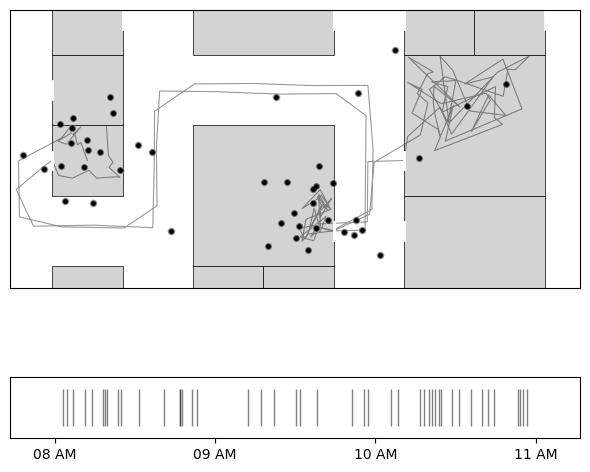

<Figure size 640x480 with 0 Axes>

In [111]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

# colors = {
#                 'street': 'white',
#                 'home': 'skyblue',
#                 'workplace': '#C9A0DC',
#                 'retail': 'lightgrey',
#                 'park': 'lightgreen',
#                 'default': 'lightcoral'
#             }

# labels = LACHESIS.lachesis_labels(
#     data=Charlie.sparse_traj,
#     dt_max=15,
#     delta_roam=2.8,
#     dur_min=5,
#     traj_cols=tc)

labels = LACHESIS.lachesis_labels(
    data=Charlie.sparse_traj,
    dt_max=1,
    delta_roam=1,
    dur_min=5)

# labels = DBSCAN.ta_dbscan(
#     data=Charlie.sparse_traj,
#     time_thresh=600,
#     dist_thresh=0.8,
#     min_pts=3,
#     dur_min=5,
#     traj_cols=tc)

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
           color='black', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_traj_only.svg', format='svg')

## Figure 3
Examples of the other failures: temporal overlaps, and many visits to one point problem (without overlaps), missingness

/var/folders/nt/0tc5pmb17xd73rr4g1xb0g_00000gn/T/ipykernel_15849/1348020903.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


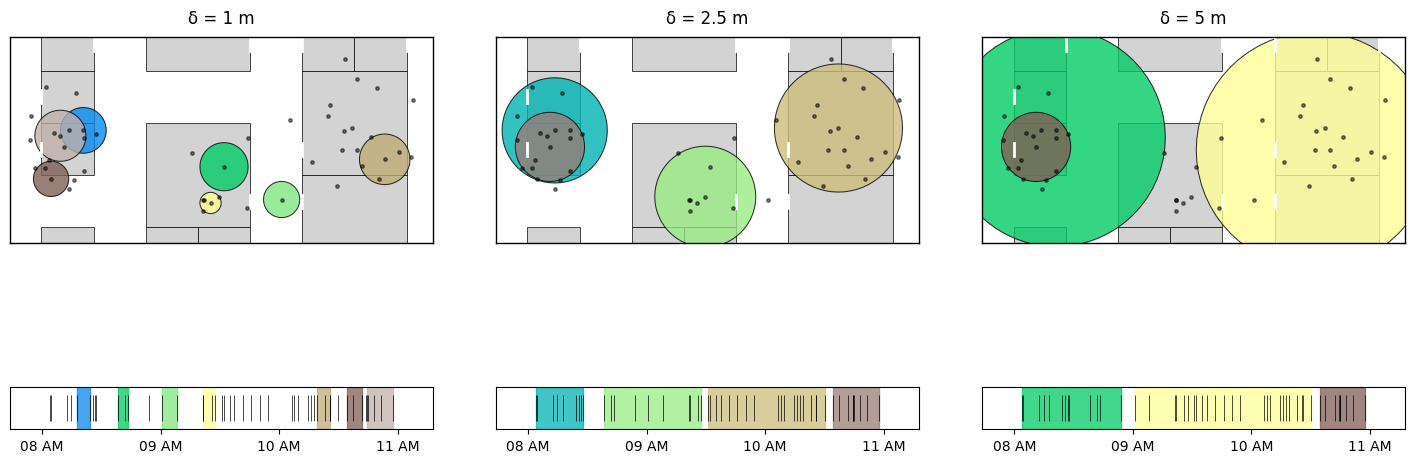

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Define delta_roam values for comparison
delta_roam_values = [3, 2.5, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 6.5),
                        gridspec_kw={'height_ratios': [10, 1], 'hspace': 0.15, 'wspace': 0.15})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2

for i, delta_roam in enumerate(delta_roam_values):
    # Run Lachesis with current delta_roam
    stops = LACHESIS.lachesis(Charlie.sparse_traj, 
                             delta_roam=delta_roam, 
                             dt_max=40, 
                             dur_min=5, 
                             complete_output=True, 
                             keep_col_names=True, 
                             timestamp='timestamp')
    
    # Map subplot
    ax_map = axes[0, i]
    ax_map.set_xlim(13.4, 21.5)
    ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
    
    city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)
    plot_stops(stops, ax=ax_map, cmap='terrain')
    plot_pings(Charlie.sparse_traj, ax=ax_map, s=6, color='black', alpha=0.5)
    
    # Add border
    ax_map.spines['top'].set_visible(True)
    ax_map.spines['right'].set_visible(True)
    ax_map.spines['bottom'].set_visible(True)
    ax_map.spines['left'].set_visible(True)
    ax_map.spines['top'].set_linewidth(1)
    ax_map.spines['right'].set_linewidth(1)
    ax_map.spines['bottom'].set_linewidth(1)
    ax_map.spines['left'].set_linewidth(1)
    ax_map.set_xticks([])
    ax_map.set_yticks([])
    
    # Add delta_roam scale indicator
    x_range = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
    y_range = ax_map.get_ylim()[1] - ax_map.get_ylim()[0]
    scale_x = ax_map.get_xlim()[1] - 0.15 * x_range
    scale_y = ax_map.get_ylim()[0] + 0.08 * y_range
    
    # Add subplot title
    ax_map.set_title(f'δ = {delta_roam} m', fontsize=12, pad=10)
    
    # Barcode subplot
    ax_barcode = axes[1, i]
    plot_time_barcode(Charlie.sparse_traj['timestamp'], ax=ax_barcode, set_xlim=True)
    plot_stops_barcode(stops, ax=ax_barcode, cmap='terrain', set_xlim=False, timestamp='timestamp')

plt.savefig('diff_deltas_clusters.svg', format='svg')
plt.tight_layout(pad=0.1)
plt.show()

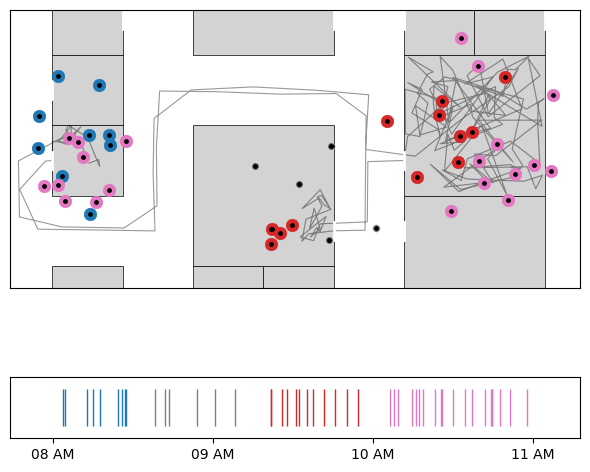

<Figure size 640x480 with 0 Axes>

In [154]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

labels_tadb = DBSCAN.ta_dbscan_labels(Charlie.sparse_traj, time_thresh=10, dist_thresh=10, min_pts=3) 

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
           color='black', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('tab10')
unique_clusters = labels_tadb.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels_tadb == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels_tadb == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], s=6, color='black', alpha=1, zorder=4)
# ax_map.scatter(Charlie.sparse_traj.loc[[1717233128,1717233423, 1717233720, 1717234213, 1717234307, 1717234686],'x'], Charlie.sparse_traj.loc[[1717233128,1717233423, 1717233720, 1717234213, 1717234307, 1717234686],'y'], s=6, color='black', alpha=1, zorder=4)

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels_tadb, ax=ax_barcode, 
                          cmap='tab10', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_traj_only.svg', format='svg')

## Figure 4
Show the relevant density for DBSCAN. 3 panels: true, true + noise, true + noise + eps_kernel <<< highlight the saddle point